In [1]:
# ── Cell 0: 한글 폰트 설정 ─────────────────────────────────────────────────
import matplotlib.pyplot as plt            # matplotlib 차트 라이브러리 임포트
import matplotlib.font_manager as fm       # 폰트 관리 모듈 임포트

# 한글 폰트 파일 경로 지정 (Windows 기본 맑은고딕)
font_path = 'C:/Windows/Fonts/malgun.ttf'
# 폰트 파일에서 폰트 이름을 추출 (예: 'Malgun Gothic')
font_name = fm.FontProperties(fname=font_path).get_name()
# matplotlib 전역 폰트를 한글 폰트로 설정 (차트 한글 깨짐 방지)
plt.rc('font', family=font_name)

In [2]:
# ── Cell 1: 라이브러리 로드 및 전역 설정 ───────────────────────────────────

import warnings                            # 경고 메시지 제어 모듈
warnings.filterwarnings('ignore')          # 모든 경고 무시 (deprecated 등 억제)

# ── 데이터 처리 및 시각화 라이브러리 ──
import pandas as pd                        # 데이터프레임 생성·조작·병합
import numpy as np                         # 배열 연산, 수학 함수
import matplotlib.pyplot as plt            # 기본 차트 (막대, 선, 산점도 등)
import seaborn as sns                      # 고급 통계 시각화 (히트맵, 상관행렬 등)
import yfinance as yf                      # Yahoo Finance API로 주가 데이터 다운로드

# ── 머신러닝 라이브러리 ──
from hmmlearn.hmm import GaussianHMM      # 가우시안 HMM (비지도 학습 기반 국면 분류)
from sklearn.preprocessing import StandardScaler       # 피처 표준화 (평균=0, 분산=1)

# ── 경기 국면 4단계 정의 ──
# 0=회복(경기 바닥→상승), 1=확장(호황), 2=둔화(고점→하락), 3=침체(불황)
PHASE_NAMES  = {0: '🌱 회복', 1: '☀️ 확장', 2: '🍂 둔화', 3: '❄️ 침체'}
# 각 국면별 차트 색상 (녹=회복, 노랑=확장, 주황=둔화, 파랑=침체)
PHASE_COLORS = {0: '#4CAF50', 1: '#FFC107', 2: '#FF9800', 3: '#2196F3'}

# HMM 상태 정렬 후 국면 매핑: rank 0(최저)→침체, 1→둔화, 2→회복, 3→확장
RANK_TO_PHASE = [3, 2, 0, 1]

# ── 분석 대상 종목 설정 ──
# S&P 500 섹터별 SPDR ETF + SOXX(반도체)
SECTOR_ETFS  = ['XLF', 'XLE', 'XLK', 'XLV', 'XLB', 'XLP', 'XLU', 'XLI', 'XLRE', 'SOXX']
# 사용자 보유 종목 (← 여기에 본인 보유 종목을 입력하세요)
MY_HOLDINGS  = ['QQQ', 'SPY']

# 설정 확인 출력
print('라이브러리 로드 완료')
print(f'섹터 ETF: {SECTOR_ETFS}')
print(f'보유 종목: {MY_HOLDINGS}')

라이브러리 로드 완료
섹터 ETF: ['XLF', 'XLE', 'XLK', 'XLV', 'XLB', 'XLP', 'XLU', 'XLI', 'XLRE', 'SOXX']
보유 종목: ['QQQ', 'SPY']


In [3]:
# ── Cell 2: FRED 매크로 경제지표 다운로드 ──────────────────────────────────
import requests, time                    # requests: HTTP 요청 / time: 재시도 대기
from io import StringIO                  # 문자열을 파일 객체처럼 변환 (pd.read_csv에 전달)

# FRED 무료 CSV 다운로드 기본 URL (시리즈 ID를 뒤에 붙여서 사용)
FRED_BASE = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id='
# 브라우저처럼 보이는 User-Agent 헤더 (FRED가 Python 기본 UA를 차단할 수 있음)
HEADERS   = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

def fetch_fred(series_id, col_name, retries=4, timeout=30):
    """FRED에서 시계열 CSV를 다운로드하고 DataFrame으로 반환.
    실패 시 지수 백오프(1→2→4→8초)로 최대 4회 재시도."""
    url = FRED_BASE + series_id            # 다운로드할 전체 URL 생성
    for attempt in range(retries):         # 최대 retries번 시도
        try:
            resp = requests.get(url, headers=HEADERS, timeout=timeout)  # HTTP GET 요청
            resp.raise_for_status()        # HTTP 에러(4xx/5xx) 발생 시 예외 던짐
            df = pd.read_csv(              # CSV 텍스트를 DataFrame으로 파싱
                StringIO(resp.text),       # 응답 텍스트를 파일 객체로 감싸기
                index_col=0,               # 첫 번째 열(날짜)을 인덱스로 사용
                parse_dates=True           # 인덱스를 datetime으로 자동 변환
            )
            df.columns = [col_name]        # 컬럼명을 사용자 지정 이름으로 변경
            df[col_name] = pd.to_numeric(  # 값을 숫자로 변환
                df[col_name], errors='coerce'  # 변환 실패 시 NaN 처리 ('.' 등)
            )
            return df                      # 성공 시 DataFrame 반환
        except Exception as e:             # 다운로드 실패 시
            if attempt < retries - 1:      # 마지막 시도가 아니면
                wait = 2 ** attempt        # 지수 백오프: 2^0=1초, 2^1=2초, 2^2=4초
                print(f'  [{series_id}] 재시도 {attempt+1}/{retries} ({wait}초 대기)...')
                time.sleep(wait)           # 대기 후 재시도
            else:
                raise                      # 마지막 시도도 실패하면 예외를 호출자에게 전파

print('FRED 데이터 다운로드 중...')

# ── 8개 FRED 시리즈 다운로드 ──
# 1) 산업생산지수 (월별, 지수) → PMI 유사 지수로 변환 예정
df_indpro   = fetch_fred('INDPRO',  'indpro')
print('  ✓ INDPRO (산업생산지수)')

# 2) 10년-3개월 국채 금리차 (%, 일별→월별 리샘플링)
df_yield    = fetch_fred('T10Y3M',  'yield_spread')
print('  ✓ T10Y3M (장단기 금리차)')

# 3) 시카고 연준 국가 금융환경지수 (주별, 지수)
#    양수=긴축적 / 음수=완화적 / 0=평균적 금융환경
df_anfci    = fetch_fred('ANFCI',   'anfci')
print('  ✓ ANFCI (금융환경지수)')

# 4) 신규 실업급여 청구건수 (주별, 천 명)
#    고용시장 선행지표: 증가=해고 증가=경기 악화 신호
df_icsa     = fetch_fred('ICSA',    'icsa')
print('  ✓ ICSA (신규 실업급여)')

# 5) 신규 건축 허가건수 (월별, 천 호)
#    주택시장 선행지표: 증가=건설 투자 증가=경기 회복 신호
df_permit   = fetch_fred('PERMIT',  'permit')
print('  ✓ PERMIT (건축허가)')

# 6) 실질 소매판매 (월별, 백만 달러, 인플레이션 조정)
#    소비 동행지표: 물가 영향 제거한 실질 소비 수준
df_rrsfs    = fetch_fred('RRSFS',   'real_retail')
print('  ✓ RRSFS (실질 소매판매)')

# 7) 비방위 자본재 신규주문 - 항공기 제외 (월별, 백만 달러)
#    기업 투자 선행지표: 설비투자 의향 반영
df_capex    = fetch_fred('ANDENO',  'capex_orders')
print('  ✓ ANDENO (자본재 주문)')

# 8) 실질 개인소득 (이전지출 제외, 월별, 십억 달러)
#    소득 동행지표: 실질 구매력 수준
df_w875rx1  = fetch_fred('W875RX1', 'real_income')
print('  ✓ W875RX1 (실질 개인소득)')

# ── INDPRO → PMI 유사 지수 변환 ──
# INDPRO 원본은 절대 지수(예: 103.5)이므로 3개월 변화율(%)로 모멘텀 산출
indpro_mom = df_indpro['indpro'].pct_change(3) * 100       # 3개월 전 대비 변화율 (%)
# 120개월(10년) rolling 윈도우에서 z-score 계산:
#   z = (현재값 - 10년 평균) / 10년 표준편차
#   → z * 10 + 50 으로 변환하면 평균=50, 표준편차=10인 PMI 유사 스케일
pmi_series = indpro_mom.rolling(120, min_periods=36).apply(
    lambda x: np.clip(
        (x.iloc[-1] - x.mean()) / max(x.std(), 0.01) * 10 + 50,
        10, 90
    ),
    raw=False
)
df_pmi = pmi_series.rename('pmi').dropna().to_frame()

# ── 파생 변수 변환 ──

# ICSA (주별) → 월별 평균으로 리샘플링 후 YoY% 변환
df_icsa = df_icsa.resample('MS').mean()                     # 주별→월별 평균
df_icsa['icsa_yoy'] = df_icsa['icsa'].pct_change(12) * 100 # 전년동월비 증가율(%)
df_icsa = df_icsa[['icsa_yoy']].dropna()

# ANFCI (주별) → 월별 평균으로 리샘플링 (원본 지수 그대로 사용)
df_anfci = df_anfci.resample('MS').mean()

# PERMIT → YoY% 변환 (건축허가 전년동월비)
df_permit['permit_yoy'] = df_permit['permit'].pct_change(12) * 100
df_permit = df_permit[['permit_yoy']].dropna()

# RRSFS (실질 소매판매) → YoY% 변환
df_rrsfs['real_retail_yoy'] = df_rrsfs['real_retail'].pct_change(12) * 100
df_rrsfs = df_rrsfs[['real_retail_yoy']].dropna()

# ANDENO (자본재 주문) → YoY% 변환
df_capex['capex_yoy'] = df_capex['capex_orders'].pct_change(12) * 100
df_capex = df_capex[['capex_yoy']].dropna()

# W875RX1 (실질 개인소득) → YoY% 변환
df_w875rx1['real_income_yoy'] = df_w875rx1['real_income'].pct_change(12) * 100
df_w875rx1 = df_w875rx1[['real_income_yoy']].dropna()

# ── 8개 매크로 지표를 하나의 DataFrame으로 병합 ──
macro = (df_pmi                              # PMI 유사 지수 (기준 DataFrame)
         .join(df_yield,    how='outer')     # + 장단기 금리차
         .join(df_anfci,    how='outer')     # + 금융환경지수
         .join(df_icsa,     how='outer')     # + 신규 실업급여 YoY%
         .join(df_permit,   how='outer')     # + 건축허가 YoY%
         .join(df_rrsfs,    how='outer')     # + 실질 소매판매 YoY%
         .join(df_capex,    how='outer')     # + 자본재 주문 YoY%
         .join(df_w875rx1,  how='outer'))    # + 실질 개인소득 YoY%
macro = macro.resample('MS').last()          # 월 시작일 기준으로 리샘플링
macro = macro.dropna()                       # 결측값이 있는 행 제거

# 결과 확인 출력
print(f'\n매크로 데이터: {macro.shape} | {macro.index[0].date()} ~ {macro.index[-1].date()}')
print(f'변수: {list(macro.columns)}')
macro.tail()

FRED 데이터 다운로드 중...
  ✓ INDPRO (산업생산지수)
  ✓ T10Y3M (장단기 금리차)
  ✓ ANFCI (금융환경지수)
  ✓ ICSA (신규 실업급여)
  ✓ PERMIT (건축허가)
  ✓ RRSFS (실질 소매판매)
  ✓ ANDENO (자본재 주문)
  ✓ W875RX1 (실질 개인소득)

매크로 데이터: (395, 8) | 1993-02-01 ~ 2025-12-01
변수: ['pmi', 'yield_spread', 'anfci', 'icsa_yoy', 'permit_yoy', 'real_retail_yoy', 'capex_yoy', 'real_income_yoy']


,pmi,yield_spread,anfci,icsa_yoy,permit_yoy,real_retail_yoy,capex_yoy,real_income_yoy
observation_date,,,,,,,,
2025-08-01,52.080601,0.00,-0.514864,-0.346620,-9.891599,1.976183,13.532764,0.873625
2025-09-01,50.575221,0.14,-0.529713,4.333333,-1.324965,1.088718,12.378193,0.911471
2025-10-01,47.586291,0.22,-0.552916,-4.021164,-1.190476,0.628331,7.906888,0.636361
2025-11-01,48.888475,0.14,-0.555388,-0.820419,-7.957560,0.502014,32.185629,0.458707
2025-12-01,49.430950,0.51,-0.559117,-1.462317,-2.162162,-0.218743,20.494365,0.226416


FRED 에서 매크로 데이터 지표 다운로드

In [4]:
# ── Cell 3: 섹터 ETF + 보유 종목 월별 수익률 다운로드 ─────────────────────
# 섹터 ETF + 보유 종목을 하나의 리스트로 합침
ALL_TICKERS = SECTOR_ETFS + MY_HOLDINGS

# 섹터 ETF(XLF 등)는 1998-12-22 상장 → 그 이전 데이터는 존재하지 않음
ETF_START   = '1999-01-01'
# 매크로 데이터 시작일과 ETF 상장일 중 더 늦은 날짜를 시작일로 사용
START_DATE  = max(str(macro.index[0].date()), ETF_START)

print(f'{len(ALL_TICKERS)}개 종목 다운로드 중... (시작: {START_DATE})')

# yf.download()는 일괄 다운로드 시 간헐적 실패가 많음
# → yf.Ticker().history()로 종목 하나씩 개별 다운로드 (더 안정적)
frames = {}                                # 종목별 종가를 담을 딕셔너리
for ticker in ALL_TICKERS:                 # 각 종목에 대해 반복
    try:
        t = yf.Ticker(ticker)              # Yahoo Finance 종목 객체 생성
        hist = t.history(                  # 과거 주가 데이터 요청
            start=START_DATE,              # 시작일
            auto_adjust=True               # 수정주가(배당·분할 반영) 사용
        )
        if len(hist) > 0:                  # 데이터가 존재하면
            frames[ticker] = hist['Close'] # 종가(Close) 컬럼만 저장
            print(f'  ✓ {ticker}: {len(hist)}일')  # 성공 로그
        else:
            print(f'  ✗ {ticker}: 데이터 없음')     # 빈 데이터
    except Exception as e:
        print(f'  ✗ {ticker}: {e}')        # 에러 발생 시 메시지 출력

# 딕셔너리 → DataFrame 변환 (열=종목, 행=날짜)
raw = pd.DataFrame(frames)
# 인덱스를 DatetimeIndex로 명시적 변환 (문자열 인덱스 방지)
raw.index = pd.to_datetime(raw.index)

# yfinance 1.2+는 tz-aware 인덱스(예: -05:00) 반환
# FRED 데이터는 tz-naive(타임존 없음)이므로 join 시 에러 발생
# → 타임존 정보를 제거하여 형식 통일
if raw.index.tz is not None:               # 타임존 정보가 있으면
    raw.index = raw.index.tz_localize(None) # 타임존 제거 (tz-aware → tz-naive)

# 일별 종가 → 월별 종가: 각 월의 마지막 거래일 종가 사용
monthly_prices  = raw.resample('MS').last()  # MS = Month Start (월 시작일로 인덱싱)
# 월별 수익률 계산: (이번 달 종가 - 지난 달 종가) / 지난 달 종가
monthly_returns = monthly_prices.pct_change()

# 전체 수익률에서 섹터 ETF와 보유 종목을 분리 (다운로드 실패한 종목은 자동 제외)
sector_ret  = monthly_returns[[c for c in SECTOR_ETFS if c in monthly_returns.columns]]
holding_ret = monthly_returns[[c for c in MY_HOLDINGS if c in monthly_returns.columns]]

# 결과 확인 출력
print(f'\n섹터 ETF 수익률: {sector_ret.shape}')   # (행=개월수, 열=ETF수)
print(f'보유 종목 수익률: {holding_ret.shape}')
sector_ret.tail(3)                         # 최근 3개월 수익률 미리보기

12개 종목 다운로드 중... (시작: 1999-01-01)
  ✓ XLF: 6835일
  ✓ XLE: 6835일
  ✓ XLK: 6834일
  ✓ XLV: 6835일
  ✓ XLB: 6835일
  ✓ XLP: 6835일
  ✓ XLU: 6835일
  ✓ XLI: 6835일
  ✓ XLRE: 2617일
  ✓ SOXX: 6198일
  ✓ QQQ: 6790일
  ✓ SPY: 6835일

섹터 ETF 수익률: (327, 10)
보유 종목 수익률: (327, 2)


,XLF,XLE,XLK,XLV,XLB,XLP,XLU,XLI,XLRE,SOXX
Date,,,,,,,,,,
2026-01-01,-0.024283,0.141803,-0.000625,-0.000388,0.086439,0.075052,0.013118,0.066529,0.026766,0.149925
2026-02-01,-0.037612,0.095397,-0.035585,0.035285,0.084027,0.077835,0.103584,0.070720,0.058170,0.017297
2026-03-01,-0.022263,0.010551,0.010233,-0.051498,-0.064407,-0.050605,-0.019170,-0.040872,-0.024635,-0.058191


In [5]:
# ── Cell 4: 파생 피처 생성 및 데이터 병합 ──────────────────────────────────
# 매크로 지표 원본을 복사 (원본 보존)
feat = macro.copy()
# PMI 3개월 변화량: 3개월 전 PMI와의 차이 → 경기 모멘텀 방향 (양수=개선, 음수=악화)
feat['pmi_chg3m']     = feat['pmi'].diff(3)
# 자본재 주문 YoY% 3개월 변화량 → 기업 투자 모멘텀 가속/감속
feat['capex_yoy_chg3m'] = feat['capex_yoy'].diff(3)

# 매크로 피처(feat) + 섹터 ETF 수익률(sector_ret)을 날짜 기준으로 병합
df = feat.join(sector_ret,  how='left')
# 보유 종목 수익률(holding_ret)도 같은 방식으로 병합
df = df.join(holding_ret,   how='left')
# 결측값이 있는 행 제거 (diff로 인한 첫 3행, ETF 상장 전 기간 등)
df = df.dropna()

# 모델 학습에 사용할 10개 피처 목록 정의
# pmi: 산업생산 기반 경기 지수 (50 중심, 동행)
# yield_spread: 10년-3개월 금리차 (음수=역전=침체 신호, 선행)
# anfci: 금융환경지수 (양수=긴축, 음수=완화, M2 대체)
# icsa_yoy: 신규 실업급여 전년비 (고용 선행)
# permit_yoy: 건축허가 전년비 (주택 선행)
# real_retail_yoy: 실질 소매판매 전년비 (소비 동행)
# capex_yoy: 자본재 주문 전년비 (투자 선행)
# real_income_yoy: 실질 개인소득 전년비 (소득 동행)
# pmi_chg3m: PMI 3개월 모멘텀 (경기 방향)
# capex_yoy_chg3m: 자본재 주문 YoY 3개월 변화 (투자 가속도)
FEATURE_COLS = ['pmi', 'yield_spread', 'anfci', 'icsa_yoy',
                'permit_yoy', 'real_retail_yoy', 'capex_yoy',
                'real_income_yoy', 'pmi_chg3m', 'capex_yoy_chg3m']

# 결과 확인 출력
print(f'결합 데이터: {df.shape} | {df.index[0].date()} ~ {df.index[-1].date()}')
print(f'피처 {len(FEATURE_COLS)}개: {FEATURE_COLS}')
df[FEATURE_COLS].describe()

결합 데이터: (122, 22) | 2015-11-01 ~ 2025-12-01
피처 10개: ['pmi', 'yield_spread', 'anfci', 'icsa_yoy', 'permit_yoy', 'real_retail_yoy', 'capex_yoy', 'real_income_yoy', 'pmi_chg3m', 'capex_yoy_chg3m']


,pmi,yield_spread,anfci,icsa_yoy,permit_yoy,real_retail_yoy,capex_yoy,real_income_yoy,pmi_chg3m,capex_yoy_chg3m
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,49.258885,0.457623,-0.423204,46.079246,2.715438,2.156363,4.192099,2.416755,0.013477,0.779750
std,10.041342,1.022680,0.174344,246.045426,11.754002,5.867966,16.406220,2.055755,14.240049,16.097315
min,10.000000,-1.880000,-0.673963,-87.369324,-26.562500,-19.939481,-26.081754,-5.851823,-36.335908,-50.956359
25%,46.911607,-0.135000,-0.553027,-11.126546,-4.032271,0.396364,-6.173873,1.353725,-5.422601,-8.225067
50%,49.457701,0.570000,-0.474064,-3.696284,2.884720,1.405063,3.339526,2.622074,-0.704641,1.415247
75%,52.568334,1.267500,-0.292625,2.601272,8.795991,2.513434,12.122353,3.538814,4.471483,10.454264
max,90.000000,2.110000,0.378117,2123.241955,59.944238,45.822693,64.489123,11.541084,80.000000,59.618913


매크로 피처 + 섹터 ETF 수익률 + 보유 종목 수익률

학습 피처 정의

HMM 학습 완료 (covariance: full)

HMM 상태 → 경기국면 매핑:
  state 0 → 🌱 회복  (복합점수: 0.1591)
  state 1 → 🍂 둔화  (복합점수: 0.0625)
  state 2 → ❄️ 침체  (복합점수: -4.2356)
  state 3 → ☀️ 확장  (복합점수: 0.5226)

Log-likelihood: -481.81
Per-sample LL: -3.9493


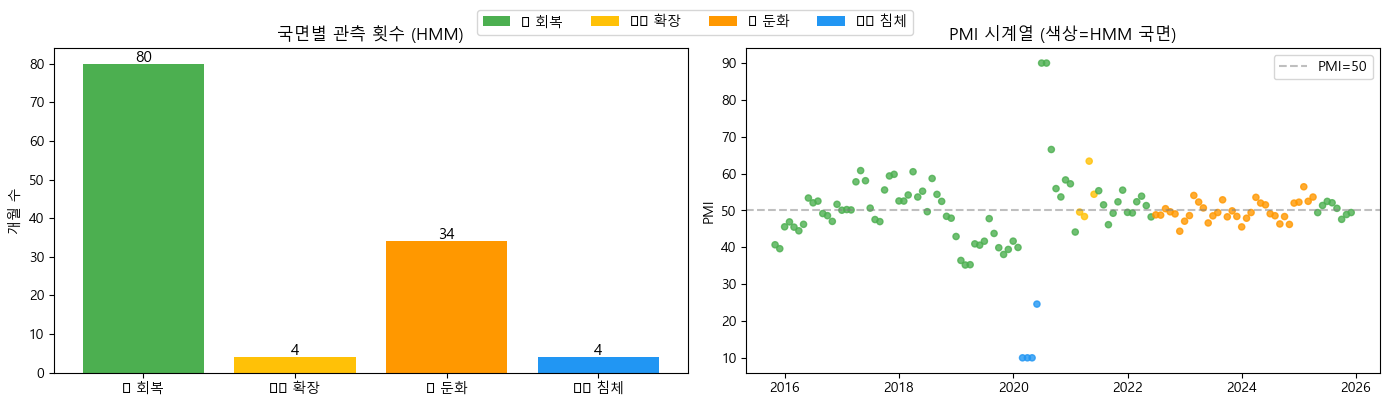


국면 분포:
  🌱 회복: 80개월 (65.6%)
  ☀️ 확장: 4개월 (3.3%)
  🍂 둔화: 34개월 (27.9%)
  ❄️ 침체: 4개월 (3.3%)


In [6]:
# ── Cell 5: HMM 학습 + 경기 국면 매핑 + 시각화 ────────────────────────────

def map_states_to_phases(model, pmi_idx=0, pmi_chg_idx=8):
    """HMM hidden states → 경기국면 매핑 (PMI 수준 + 모멘텀 복합점수 기준).
    
    PMI가 높고 모멘텀이 양수인 상태 = 확장,
    PMI가 낮은 상태 = 침체, 중간이면서 모멘텀으로 회복/둔화 구분.
    
    Returns: {hmm_state_id: phase_id} 예: {2: 0, 0: 1, 3: 2, 1: 3}
    """
    # 복합점수: PMI 수준 + 0.5 × PMI 3개월 모멘텀
    scores = model.means_[:, pmi_idx] + 0.5 * model.means_[:, pmi_chg_idx]
    sorted_states = np.argsort(scores)  # 낮은 순 정렬
    return {int(sid): RANK_TO_PHASE[rank] for rank, sid in enumerate(sorted_states)}

# ── 피처 스케일링 ──
X = df[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── GaussianHMM 학습 (4개 상태 = 4개 경기국면) ──
# full 공분산 시도 → 실패 시 diag 폴백 (feature1_regime.py와 동일 패턴)
for cov_type in ('full', 'diag'):
    try:
        model = GaussianHMM(
            n_components=4,            # 4개 경기국면 (회복/확장/둔화/침체)
            covariance_type=cov_type,   # full: 피처 간 상관관계 학습
            n_iter=200,                 # EM 알고리즘 최대 반복 횟수
            random_state=42,            # 재현성 보장
        )
        model.fit(X_scaled)            # EM 알고리즘으로 파라미터 추정
        print(f'HMM 학습 완료 (covariance: {cov_type})')
        break
    except (ValueError, np.linalg.LinAlgError):
        if cov_type == 'diag':
            raise

# ── 상태 예측 및 국면 매핑 ──
states = model.predict(X_scaled)                # Viterbi로 최적 상태 시퀀스 추론
state_to_phase = map_states_to_phases(model)    # HMM 상태 → 경기국면 매핑
df['phase'] = [state_to_phase[s] for s in states]

# 매핑 결과 출력
print('\nHMM 상태 → 경기국면 매핑:')
for s in range(4):
    ph = state_to_phase[s]
    score = model.means_[s, 0] + 0.5 * model.means_[s, 8]
    print(f'  state {s} → {PHASE_NAMES[ph]}  (복합점수: {score:.4f})')

print(f'\nLog-likelihood: {model.score(X_scaled):.2f}')
print(f'Per-sample LL: {model.score(X_scaled)/len(X_scaled):.4f}')

# ── 시각화: 국면 분포 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# [좌측] 국면별 관측 횟수 막대 그래프
counts = df['phase'].value_counts().sort_index()
colors = [PHASE_COLORS[i] for i in counts.index]
axes[0].bar(
    [PHASE_NAMES[i] for i in counts.index],
    counts.values,
    color=colors
)
axes[0].set_title('국면별 관측 횟수 (HMM)')
axes[0].set_ylabel('개월 수')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=11)

# [우측] PMI 시계열 산점도 — 색상이 HMM 예측 국면
axes[1].scatter(
    df.index, df['pmi'],
    c=[PHASE_COLORS[p] for p in df['phase']],
    s=20, alpha=0.8
)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5, label='PMI=50')
axes[1].set_title('PMI 시계열 (색상=HMM 국면)')
axes[1].set_ylabel('PMI')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PHASE_COLORS[k], label=PHASE_NAMES[k]) for k in range(4)]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

# 국면별 분포 텍스트 출력
print('\n국면 분포:')
for ph, cnt in counts.items():
    print(f'  {PHASE_NAMES[ph]}: {cnt}개월 ({cnt/len(df)*100:.1f}%)')

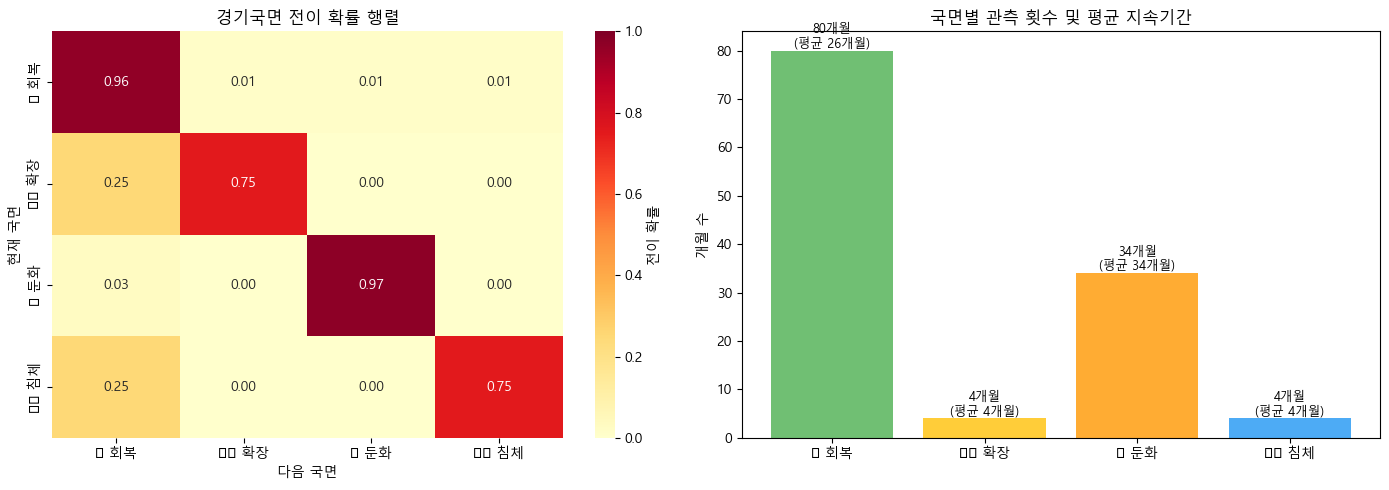

Per-sample Log-likelihood: -3.9493
전체 데이터: 122개월

전이 확률 요약:
  🌱 회복: 자기전이 96.2% → 평균 지속 26.3개월
  ☀️ 확장: 자기전이 75.0% → 평균 지속 4.0개월
  🍂 둔화: 자기전이 97.1% → 평균 지속 34.0개월
  ❄️ 침체: 자기전이 75.0% → 평균 지속 4.0개월


In [7]:
# ── Cell 6: HMM 모델 평가 ──────────────────────────────────────────────
# HMM은 비지도학습이므로 train/test 분할 없이 전체 데이터로 학습
# 대신 log-likelihood와 전이확률 행렬로 모델 품질 평가

# ── 전이 확률 행렬 시각화 ──
trans_mat = model.transmat_
phase_labels = [PHASE_NAMES[state_to_phase[s]] for s in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [좌측] 전이 확률 히트맵 (HMM 상태 기준을 국면으로 변환)
# 국면 순서로 재배열
phase_order = []
for ph in range(4):  # 회복, 확장, 둔화, 침체 순
    for s in range(4):
        if state_to_phase[s] == ph:
            phase_order.append(s)
            break

reordered = trans_mat[np.ix_(phase_order, phase_order)]
reordered_labels = [PHASE_NAMES[state_to_phase[s]] for s in phase_order]

sns.heatmap(
    reordered, annot=True, fmt='.2f',
    cmap='YlOrRd',
    xticklabels=reordered_labels,
    yticklabels=reordered_labels,
    ax=axes[0],
    vmin=0, vmax=1,
    cbar_kws={'label': '전이 확률'}
)
axes[0].set_title('경기국면 전이 확률 행렬')
axes[0].set_xlabel('다음 국면')
axes[0].set_ylabel('현재 국면')

# [우측] 국면별 샘플 수 + 평균 지속 기간
x = np.arange(4)
counts_ordered = [int((df['phase'] == ph).sum()) for ph in range(4)]
# 평균 지속 기간 = 1 / (1 - 자기전이확률)
durations = [1 / (1 - reordered[i, i]) if reordered[i, i] < 1 else float('inf') for i in range(4)]

bars = axes[1].bar(
    [PHASE_NAMES[ph] for ph in range(4)],
    counts_ordered,
    color=[PHASE_COLORS[ph] for ph in range(4)],
    alpha=0.8
)
axes[1].set_title('국면별 관측 횟수 및 평균 지속기간')
axes[1].set_ylabel('개월 수')
for i, (v, d) in enumerate(zip(counts_ordered, durations)):
    axes[1].text(i, v + 0.5, f'{v}개월\n(평균 {d:.0f}개월)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 모델 성능 요약
avg_ll = model.score(X_scaled) / len(X_scaled)
print(f'Per-sample Log-likelihood: {avg_ll:.4f}')
print(f'전체 데이터: {len(X_scaled)}개월')
print(f'\n전이 확률 요약:')
for i, ph in enumerate(range(4)):
    s = phase_order[i]
    self_prob = trans_mat[s, s]
    print(f'  {PHASE_NAMES[ph]}: 자기전이 {self_prob:.1%} → 평균 지속 {1/(1-self_prob):.1f}개월')

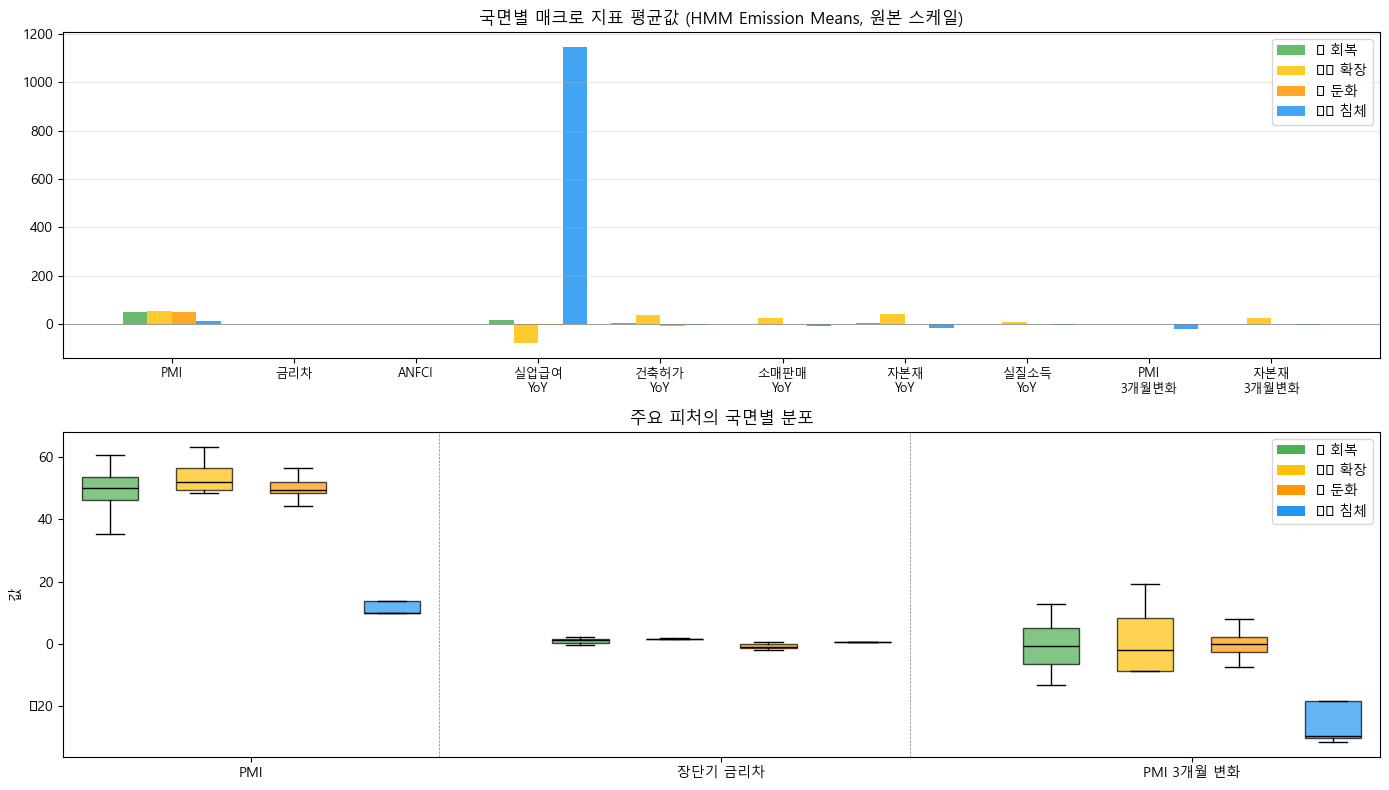


국면별 주요 지표 평균:
                  PMI      금리차    ANFCI     PMI모멘텀
--------------------------------------------------
🌱 회복             50.6     0.93    -0.48       0.78
☀️ 확장            53.9     1.58    -0.57       1.62
🍂 둔화             49.8    -0.80    -0.33       0.27
❄️ 침체            13.6     0.54     0.00     -19.11


In [8]:
# ── Cell 7: HMM 발산 분포 분석 (국면별 매크로 지표 특성) ───────────────────
# HMM 각 상태의 emission mean을 국면별로 시각화 → 국면이 경제적으로 의미 있는지 확인

# 국면 순서로 emission means 재배열
means_reordered = scaler.inverse_transform(model.means_[phase_order])
feature_labels = ['PMI', '금리차', 'ANFCI', '실업급여\nYoY', '건축허가\nYoY',
                  '소매판매\nYoY', '자본재\nYoY', '실질소득\nYoY', 'PMI\n3개월변화', '자본재\n3개월변화']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# [상단] 국면별 피처 평균값 그룹 막대 그래프
x = np.arange(len(FEATURE_COLS))
width = 0.2
for i, ph in enumerate(range(4)):
    axes[0].bar(
        x + i * width - 1.5 * width,
        means_reordered[i],
        width,
        label=PHASE_NAMES[ph],
        color=PHASE_COLORS[ph],
        alpha=0.85
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_labels, fontsize=9)
axes[0].set_title('국면별 매크로 지표 평균값 (HMM Emission Means, 원본 스케일)')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

# [하단] 주요 피처 3개의 국면별 분포 (박스플롯)
key_features = ['pmi', 'yield_spread', 'pmi_chg3m']
key_labels = ['PMI', '장단기 금리차', 'PMI 3개월 변화']

for idx, (feat, label) in enumerate(zip(key_features, key_labels)):
    ax_pos = idx  # 0, 1, 2
    for ph in range(4):
        mask = df['phase'] == ph
        vals = df.loc[mask, feat].values
        pos = idx * 5 + ph
        bp = axes[1].boxplot(
            vals, positions=[pos], widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=PHASE_COLORS[ph], alpha=0.7),
            medianprops=dict(color='black'),
            showfliers=False
        )
    # 피처 구분선
    if idx < 2:
        axes[1].axvline(idx * 5 + 3.5, color='gray', linewidth=0.5, linestyle='--')

axes[1].set_xticks([1.5, 6.5, 11.5])
axes[1].set_xticklabels(key_labels)
axes[1].set_title('주요 피처의 국면별 분포')
axes[1].set_ylabel('값')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PHASE_COLORS[k], label=PHASE_NAMES[k]) for k in range(4)]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# 국면별 매크로 특성 요약
print('\n국면별 주요 지표 평균:')
print(f'{"":12s} {"PMI":>8s} {"금리차":>8s} {"ANFCI":>8s} {"PMI모멘텀":>10s}')
print('-' * 50)
for i, ph in enumerate(range(4)):
    m = means_reordered[i]
    print(f'{PHASE_NAMES[ph]:12s} {m[0]:8.1f} {m[1]:8.2f} {m[2]:8.2f} {m[8]:10.2f}')

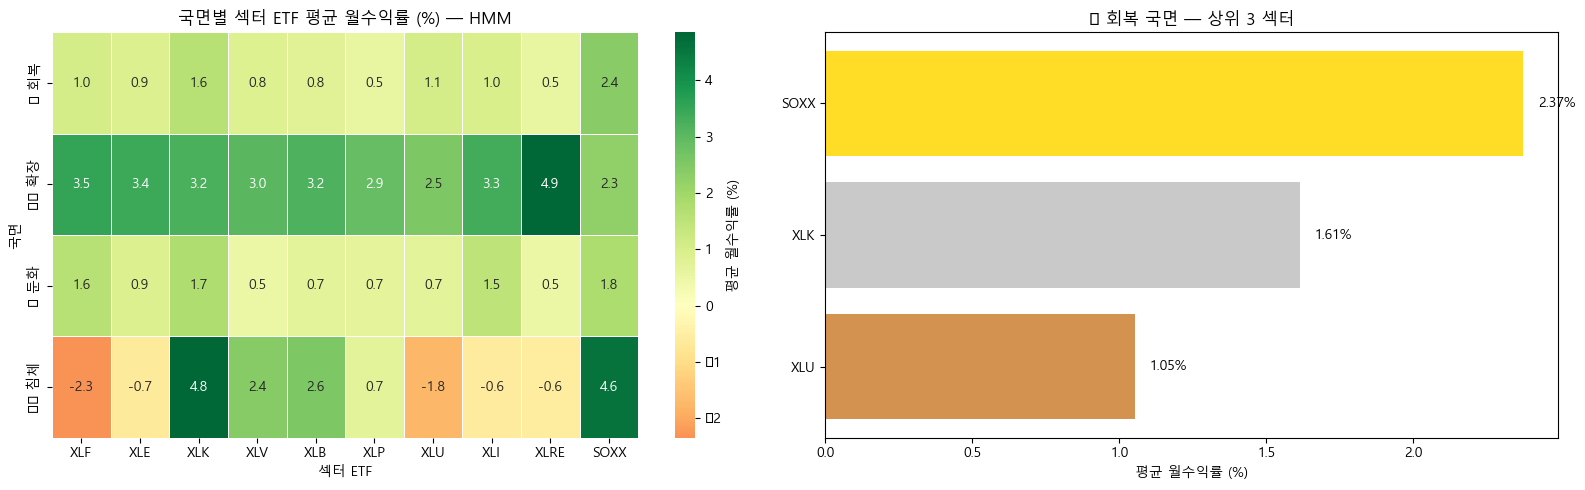


국면별 섹터 평균 월수익률 (%)
        XLF   XLE  XLK  XLV  XLB  XLP   XLU   XLI  XLRE  SOXX
🌱 회복   1.04  0.91 1.61 0.84 0.76 0.54  1.05  1.00  0.54  2.37
☀️ 확장  3.52  3.40 3.25 3.03 3.20 2.90  2.55  3.34  4.85  2.26
🍂 둔화   1.59  0.87 1.74 0.48 0.71 0.66  0.72  1.49  0.49  1.79
❄️ 침체 -2.34 -0.68 4.82 2.39 2.56 0.72 -1.77 -0.61 -0.58  4.58


In [9]:
# ── Cell 8: 국면별 섹터 ETF 성과 분석 ──────────────────────────────────────
# HMM이 분류한 국면 라벨 + 섹터 ETF 수익률 컬럼만 추출
perf_df = df[['phase'] + SECTOR_ETFS].copy()

# 국면별로 그룹화하여 각 섹터 ETF의 평균 월수익률 계산 (소수→%로 변환)
phase_sector_perf = (
    perf_df.groupby('phase')[SECTOR_ETFS]
    .mean() * 100
)
phase_sector_perf.index = [PHASE_NAMES[i] for i in phase_sector_perf.index]

# 1행 2열 차트 레이아웃
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── [좌측] 국면×섹터 히트맵 ──
sns.heatmap(
    phase_sector_perf,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': '평균 월수익률 (%)'}
)
axes[0].set_title('국면별 섹터 ETF 평균 월수익률 (%) — HMM')
axes[0].set_xlabel('섹터 ETF')
axes[0].set_ylabel('국면')

# ── [우측] 현재 국면에서 상위 3개 섹터 ──
# HMM 확률 기반으로 현재 국면 판별
all_proba = model.predict_proba(X_scaled)
latest_proba_raw = all_proba[-1]
proba_by_phase = {state_to_phase[i]: float(p) for i, p in enumerate(latest_proba_raw)}
current_phase_idx = max(proba_by_phase, key=proba_by_phase.get)

current_row = phase_sector_perf.loc[PHASE_NAMES[current_phase_idx]]
top3 = current_row.nlargest(3)

colors_top = ['gold', 'silver', '#CD7F32']
axes[1].barh(
    top3.index[::-1],
    top3.values[::-1],
    color=colors_top[::-1],
    alpha=0.85
)
axes[1].set_title(f'{PHASE_NAMES[current_phase_idx]} 국면 — 상위 3 섹터')
axes[1].set_xlabel('평균 월수익률 (%)')
for i, (name, val) in enumerate(zip(top3.index[::-1], top3.values[::-1])):
    axes[1].text(val + 0.05, i, f'{val:.2f}%', va='center')

plt.tight_layout()
plt.show()

print('\n국면별 섹터 평균 월수익률 (%)')
print(phase_sector_perf.to_string(float_format='{:.2f}'.format))

In [10]:
# ── Cell 9: 현재 경기 국면 예측 및 추천 ────────────────────────────────────
latest_date = df.index[-1]

# HMM 확률 기반 현재 국면 판별
all_proba = model.predict_proba(X_scaled)
latest_proba_raw = all_proba[-1]  # 마지막 시점의 상태별 확률
proba_by_phase = {state_to_phase[i]: float(p) for i, p in enumerate(latest_proba_raw)}
pred_phase = max(proba_by_phase, key=proba_by_phase.get)
proba_dict = {PHASE_NAMES[ph]: round(proba_by_phase.get(ph, 0.0), 4) for ph in range(4)}

# ── 예측 결과 출력 ──
print('=' * 60)
print(f'기준일: {latest_date.strftime("%Y-%m")}')
print('=' * 60)
print(f'\n  현재 국면: {PHASE_NAMES[pred_phase]}  (확률 {proba_by_phase[pred_phase]*100:.0f}%)')

# 4개 국면별 확률을 텍스트 막대로 시각화
print()
print('  국면별 확률:')
for ph in range(4):
    prob = proba_by_phase.get(ph, 0.0)
    bar = '█' * int(prob * 30)
    print(f'  {PHASE_NAMES[ph]:12s} {prob*100:5.1f}% {bar}')

# 현재 국면에서 역사적 평균 수익률이 높았던 섹터 ETF 상위 3개
print()
print('  이 국면에서 역사적으로 강한 ETF:')
top3 = phase_sector_perf.loc[PHASE_NAMES[pred_phase]].nlargest(3)
for rank, (etf, ret) in enumerate(top3.items(), 1):
    print(f'    {rank}. {etf:5s}  {ret:+.2f}% / 월')

# 전이 확률 기반 다음 국면 예측
print()
print('  다음 국면 전이 확률:')
current_state = phase_order[pred_phase]  # 현재 국면에 해당하는 HMM 상태
for next_ph in range(4):
    next_state = phase_order[next_ph]
    trans_prob = model.transmat_[current_state, next_state]
    if trans_prob > 0.01:  # 1% 이상만 표시
        arrow = '→' if next_ph != pred_phase else '↻'
        print(f'    {arrow} {PHASE_NAMES[next_ph]:12s} {trans_prob*100:5.1f}%')

# 현재 매크로 지표 수치
print()
print('  현재 매크로 지표:')
v = df[FEATURE_COLS].iloc[-1]
print(f'  PMI: {v["pmi"]:.1f} | '
      f'금리차(10Y-3M): {v["yield_spread"]:.2f}% | '
      f'금융환경(ANFCI): {v["anfci"]:.2f}')
print(f'  실업급여 YoY: {v["icsa_yoy"]:+.1f}% | '
      f'건축허가 YoY: {v["permit_yoy"]:+.1f}% | '
      f'실질소매판매 YoY: {v["real_retail_yoy"]:+.1f}%')
print(f'  자본재주문 YoY: {v["capex_yoy"]:+.1f}% | '
      f'실질소득 YoY: {v["real_income_yoy"]:+.1f}%')
print(f'  PMI 3개월변화: {v["pmi_chg3m"]:+.2f} | '
      f'자본재주문 YoY 3개월변화: {v["capex_yoy_chg3m"]:+.2f}%p')
print('=' * 60)

기준일: 2025-12

  현재 국면: 🌱 회복  (확률 100%)

  국면별 확률:
  🌱 회복         100.0% █████████████████████████████
  ☀️ 확장          0.0% 
  🍂 둔화           0.0% 
  ❄️ 침체          0.0% 

  이 국면에서 역사적으로 강한 ETF:
    1. SOXX   +2.37% / 월
    2. XLK    +1.61% / 월
    3. XLU    +1.05% / 월

  다음 국면 전이 확률:
    ↻ 🌱 회복          96.2%
    → ☀️ 확장          1.3%
    → 🍂 둔화           1.3%
    → ❄️ 침체          1.3%

  현재 매크로 지표:
  PMI: 49.4 | 금리차(10Y-3M): 0.51% | 금융환경(ANFCI): -0.56
  실업급여 YoY: -1.5% | 건축허가 YoY: -2.2% | 실질소매판매 YoY: -0.2%
  자본재주문 YoY: +20.5% | 실질소득 YoY: +0.2%
  PMI 3개월변화: -1.14 | 자본재주문 YoY 3개월변화: +8.12%p


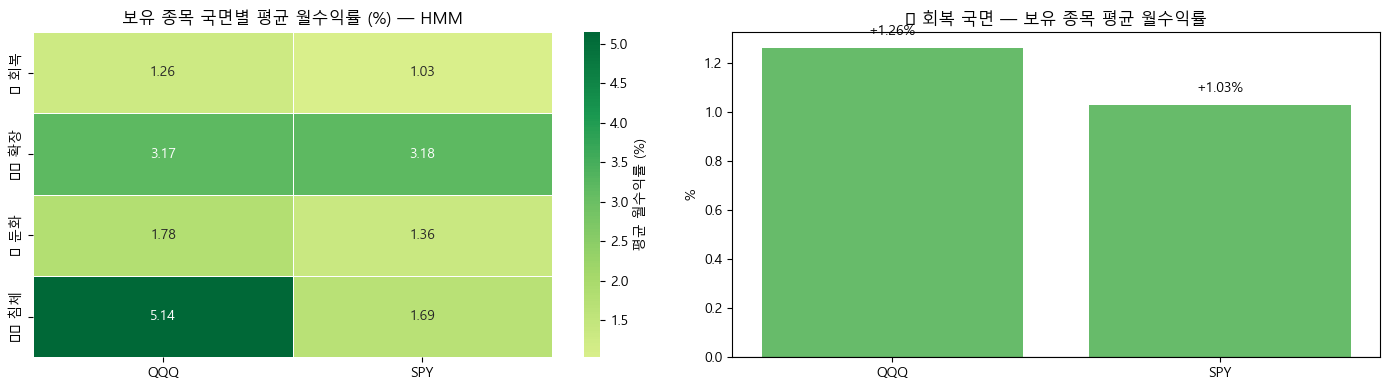


보유 종목 분석:
--------------------------------------------------
🌱 회복 (80개월): ← 현재 국면
  QQQ    → 평균 +1.26%  (80회 관측)
  SPY    → 평균 +1.03%  (80회 관측)

☀️ 확장 (4개월):
  QQQ    → 평균 +3.17%  (4회 관측)
  SPY    → 평균 +3.18%  (4회 관측)

🍂 둔화 (34개월):
  QQQ    → 평균 +1.78%  (34회 관측)
  SPY    → 평균 +1.36%  (34회 관측)

❄️ 침체 (4개월):
  QQQ    → 평균 +5.14%  (4회 관측)
  SPY    → 평균 +1.69%  (4회 관측)



In [11]:
# ── Cell 10: 보유 종목 국면별 성과 분석 ────────────────────────────────────
# HMM이 분류한 국면별 보유 종목의 평균 월수익률 계산 (소수→%로 변환)
hold_mean = df.groupby('phase')[MY_HOLDINGS].mean() * 100
hold_mean.index = [PHASE_NAMES[i] for i in hold_mean.index]

# 국면별 수익률 계산

# 1행 2열 차트 레이아웃
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── [좌측] 보유 종목의 국면별 수익률 히트맵 ──
if len(MY_HOLDINGS) > 1:
    sns.heatmap(
        hold_mean,
        annot=True, fmt='.2f',
        cmap='RdYlGn',
        center=0,
        linewidths=0.5,
        ax=axes[0],
        cbar_kws={'label': '평균 월수익률 (%)'}
    )
else:
    axes[0].bar(
        hold_mean.index,
        hold_mean[MY_HOLDINGS[0]],
        color=[PHASE_COLORS[i] for i in range(4)],
        alpha=0.8
    )
axes[0].set_title('보유 종목 국면별 평균 월수익률 (%) — HMM')

# ── [우측] 현재 국면에서의 보유 종목 성과 ──
current_hold = hold_mean.loc[PHASE_NAMES[pred_phase]]
bar_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in current_hold.values]
axes[1].bar(
    current_hold.index,
    current_hold.values,
    color=bar_colors,
    alpha=0.85
)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'{PHASE_NAMES[pred_phase]} 국면 — 보유 종목 평균 월수익률')
axes[1].set_ylabel('%')
for i, (ticker, val) in enumerate(zip(current_hold.index, current_hold.values)):
    offset = 0.05 if val >= 0 else -0.15
    axes[1].text(i, val + offset, f'{val:+.2f}%', ha='center')

plt.tight_layout()
plt.show()

# ── 텍스트 요약 ──
print('\n보유 종목 분석:')
print('-' * 50)
for phase_idx in range(4):
    phase_mask = df['phase'] == phase_idx
    n = phase_mask.sum()
    if n == 0:
        continue
    is_current = ' ← 현재 국면' if phase_idx == pred_phase else ''
    print(f'{PHASE_NAMES[phase_idx]} ({n}개월):{is_current}')
    for ticker in MY_HOLDINGS:
        avg_ret = df.loc[phase_mask, ticker].mean() * 100
        obs_cnt = df.loc[phase_mask, ticker].count()
        print(f'  {ticker:6s} → 평균 {avg_ret:+.2f}%  ({obs_cnt}회 관측)')
    print()